<a href="https://colab.research.google.com/github/Pratyush-coding/Amazon-Project/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/train.csv'
)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


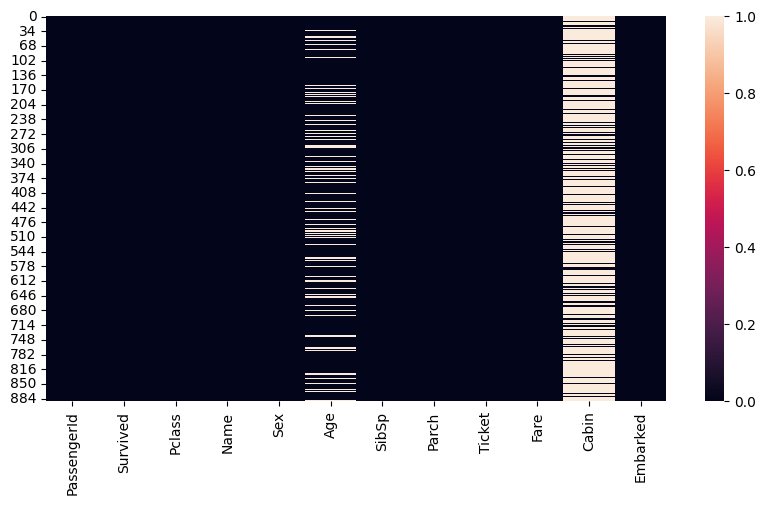

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull())

plt.show()

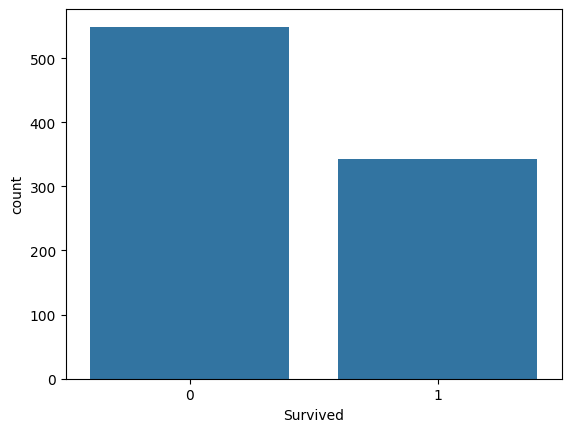

In [ ]:
sns.countplot(x="Survived", data=df)

plt.show()

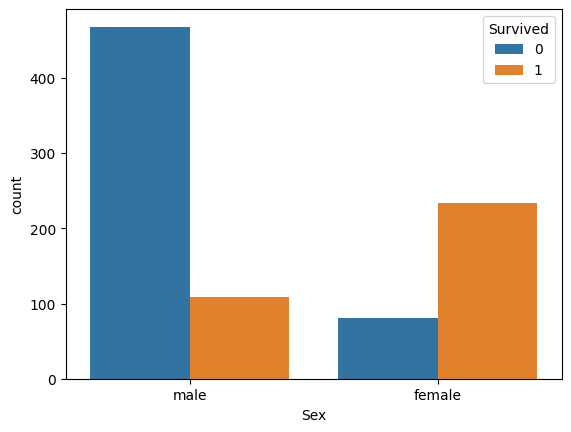

In [ ]:
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.show()

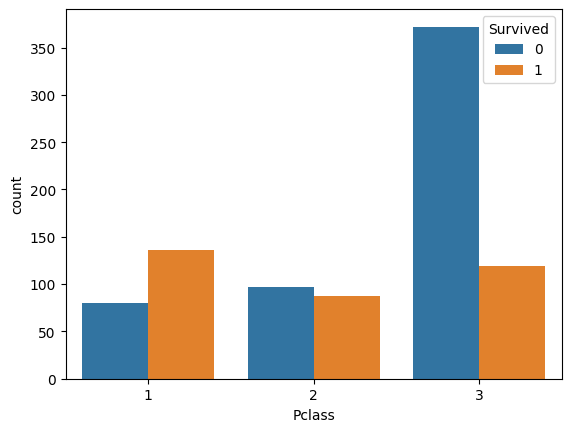

In [ ]:
sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.show()

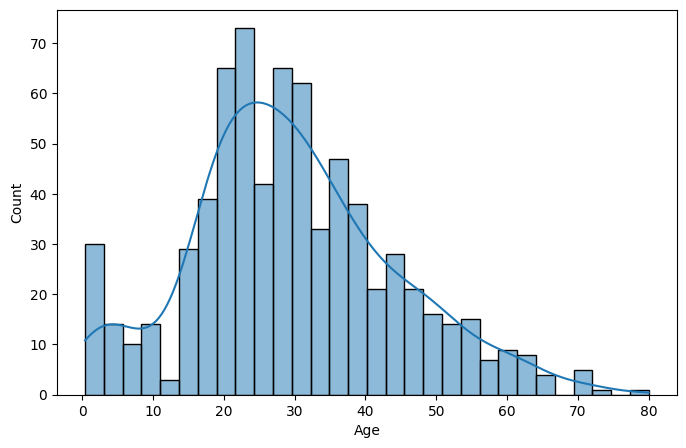

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.show()

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


**Part-2**

In [ ]:
df.drop(
    ["PassengerId", "Name", "Ticket", "Cabin"],
    axis=1,
    inplace=True
)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [ ]:
df["Sex"].head()

,Sex
0,male
1,female
2,female
3,female
4,male


In [ ]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [ ]:
df["Sex"].head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [ ]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked_Q,0
Embarked_S,0


In [ ]:
df["Embarked_Q"] = df["Embarked_Q"].astype(int)
df["Embarked_S"] = df["Embarked_S"].astype(int)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


In [ ]:
y = df["Survived"]

X = df.drop("Survived", axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(712, 8)
(179, 8)


**Phase-2(Part-1)**

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[90 15]
 [19 55]]


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
feature_names = X.columns

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Sex,1.277104
5,Fare,0.126511
6,Embarked_Q,-0.046058
4,Parch,-0.096142
7,Embarked_S,-0.189423
3,SibSp,-0.349952
2,Age,-0.396152
0,Pclass,-0.785328


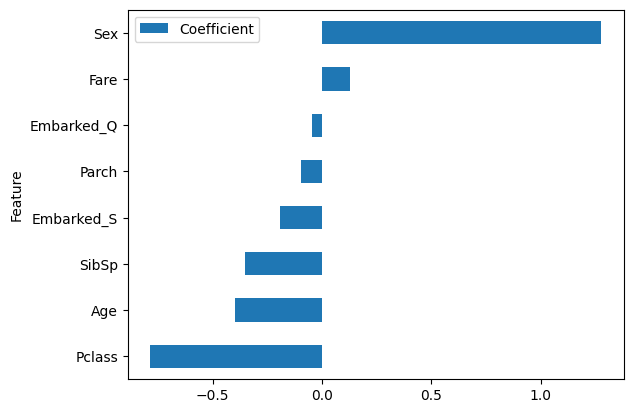

In [ ]:
import matplotlib.pyplot as plt

coefficients.sort_values(
    by="Coefficient"
).plot(
    x="Feature",
    y="Coefficient",
    kind="barh"
)

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
tree = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
tree.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_tree = tree.predict(
    X_test
)

In [ ]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print(tree_accuracy)

0.7877094972067039


In [ ]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print(cm_tree)

[[86 19]
 [19 55]]


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Sex,0.310280
5,Fare,0.263543
2,Age,0.206181
0,Pclass,0.111937
3,SibSp,0.059694
4,Parch,0.027496
7,Embarked_S,0.016200
6,Embarked_Q,0.004669


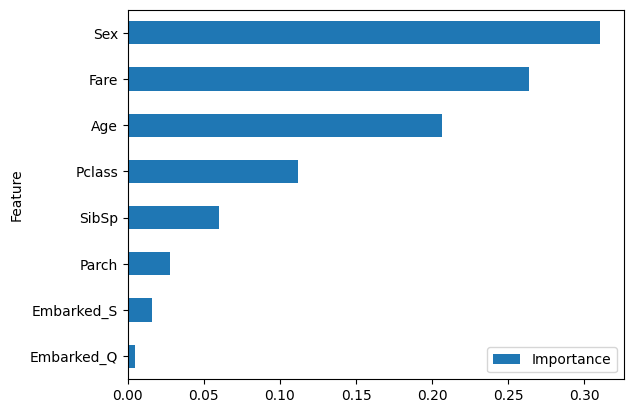

In [ ]:
importance.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.show()

In [ ]:
train_pred = tree.predict(
    X_train
)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

print(train_accuracy)

0.9789325842696629


In [ ]:
tree_depth3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

In [ ]:
tree_depth3.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
pred_depth3 = tree_depth3.predict(
    X_test
)

In [ ]:
accuracy_depth3 = accuracy_score(
    y_test,
    pred_depth3
)

print(accuracy_depth3)

0.7988826815642458


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.810056
1        Decision Tree  0.787709


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    random_state=42
)

In [ ]:
rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(
    X_test
)

In [ ]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("RF Accuracy:", rf_accuracy)

RF Accuracy: 0.7988826815642458


In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[88 17]
 [19 55]]


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
train_pred_rf = rf.predict(
    X_train
)

train_accuracy_rf = accuracy_score(
    y_train,
    train_pred_rf
)

print(train_accuracy_rf)

0.9789325842696629


In [ ]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_rf.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
5,Fare,0.273568
1,Sex,0.268369
2,Age,0.253454
0,Pclass,0.080003
3,SibSp,0.054522
4,Parch,0.037680
7,Embarked_S,0.022740
6,Embarked_Q,0.009663


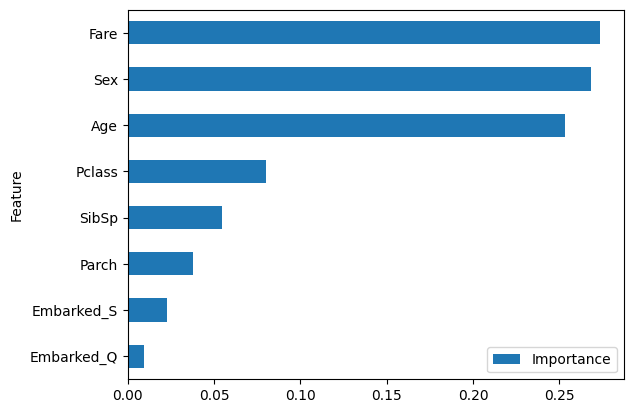

In [ ]:
importance_rf.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.show()

In [ ]:
rf10 = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

rf10.fit(X_train, y_train)

pred10 = rf10.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred10
    )
)

0.7988826815642458


In [ ]:
rf50 = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

rf50.fit(X_train, y_train)

pred50 = rf50.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred50
    )
)

0.8044692737430168


In [ ]:
rf100 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf100.fit(X_train, y_train)

pred100 = rf100.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred100
    )
)

0.7988826815642458


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Decision Tree Depth=3",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        accuracy_depth3,
        rf_accuracy
    ]
})

print(results)

                   Model  Accuracy
0    Logistic Regression  0.810056
1          Decision Tree  0.787709
2  Decision Tree Depth=3  0.798883
3          Random Forest  0.798883
